In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
filename = "1_f.csv"

In [3]:
rr = pd.read_csv(filename, header=None)[0].to_numpy(dtype=float)
n = len(rr)
print(f"Число интервалов n = {n}")

Число интервалов n = 300


## Часть 1. Статистические методы.

In [4]:
# Основные показатели ВСР

# ЧСС в минуту
HR = 60 * 1000 * len(rr) / sum(rr)

# Среднее значение интервалов RR (M, мс)
M = rr.mean()

#SDNN (мс)–стандартное отклонение RR
SDNN = rr.std(ddof=1)

# Коэффициент вариации CV (%)
CV = SDNN / M * 100

# RMSSD (мс)-корень из среднего квадрата разностей соседних интервалов
diffs = np.diff(rr)
RMSSD = np.sqrt(np.mean(diffs**2))

# pNN50 (%) – доля пар соседних интервалов, различающихся > 50 мс
pNN50 = np.sum(np.abs(diffs) > 50) / len(diffs) * 100

In [5]:
print(f"HR     = {HR:.2f} ударов в 1 мин")
print(f"M      = {M:.2f} мс")
print(f"SDNN   = {SDNN:.2f} мс")
print(f"CV     = {CV:.2f} %")
print(f"RMSSD  = {RMSSD:.2f} мс")
print(f"pNN50  = {pNN50:.2f} %")

HR     = 80.56 ударов в 1 мин
M      = 744.80 мс
SDNN   = 38.70 мс
CV     = 5.20 %
RMSSD  = 37.40 мс
pNN50  = 19.06 %


Вариационная гистограмма(пулсьограмма)

In [6]:
# Бины 400–1300 мс, шаг 50 мс
bin_width = 50
bins = np.arange(400, 1300 + bin_width, bin_width)

hist_counts, bin_edges = np.histogram(rr, bins=bins)
rel_freq = hist_counts / n  # относительные частоты

In [7]:
# Определение моды: бин с максимальным количеством
idx_mode = np.argmax(hist_counts)
Mo_left = bin_edges[idx_mode]
Mo_right = bin_edges[idx_mode + 1]
Mo = (Mo_left + Mo_right) / 2   # модальное значение RR (по центру бина)
AMo = hist_counts[idx_mode] / n * 100  # амплитуда моды в %

In [8]:
# Вариационный размах
Mx = rr.max()
Mn = rr.min()
MxDMn = Mx - Mn

In [9]:
print(f"Мо    = {Mo:.1f} мс")
print(f"АМо   = {AMo:.2f} %")
print(f"Mx    = {Mx:.1f} мс")
print(f"Mn    = {Mn:.1f} мс")
print(f"MxDMn = {MxDMn:.1f} мс")

Мо    = 725.0 мс
АМо   = 43.33 %
Mx    = 844.0 мс
Mn    = 615.0 мс
MxDMn = 229.0 мс


Индекс напряжения регуляторных систем (ИН, SI)

In [10]:
# Формула Баевского:
SI = AMo / (2 * Mo * MxDMn) * 1_000_000
print(f"SI = {SI:.2f} усл. ед.")

SI = 130.50 усл. ед.


Индекс напряжения лежит в пределах нормы: 80 - 150

Гистограмма

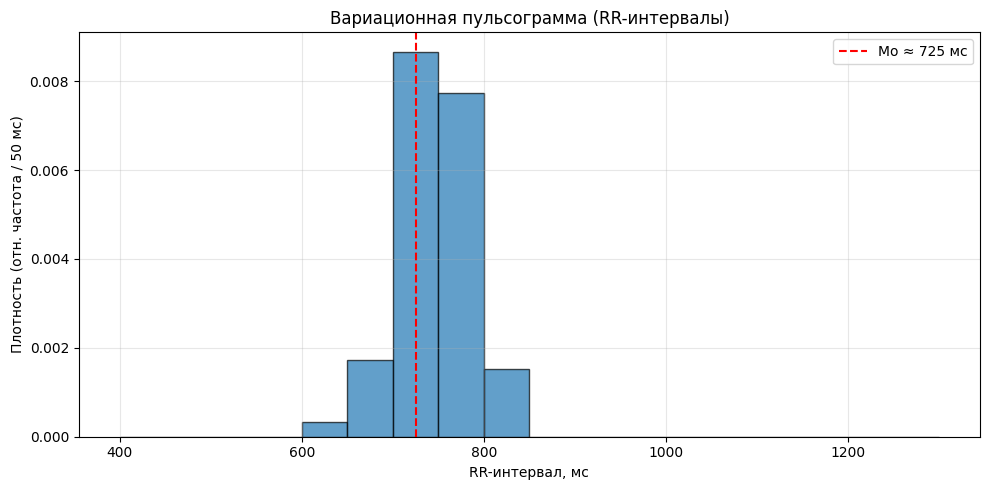

In [11]:
plt.figure(figsize=(10, 5))
# гистограмма в виде плотности (частота / ширина бина)
plt.hist(rr, bins=bins, density=True, edgecolor='black', alpha=0.7)

plt.title("Вариационная пульсограмма (RR-интервалы)")
plt.xlabel("RR-интервал, мс")
plt.ylabel("Плотность (отн. частота / 50 мс)")

# Вертикальная линия в области моды (по центру бина)
plt.axvline(Mo, color='red', linestyle='--', label=f"Мо ≈ {Mo:.0f} мс")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Часть 2. Автокорреляционный анализ.

In [12]:
#У нас уже загружены данные, импорты и таблица, посчитаны интервалы, так что переходим сразу к анализу.
# Нормируем ряд: X_i = RR_i - среднее, как обычно делают для корреляции
X = rr - rr.mean()

Автокорреляционный анализ

In [13]:
# Будем считать r(k) по выборочной формуле Пирсона для X_i и X_{i+k}
# m – число шагов смещения;
m = min(128, n - 2)

r = []  # автокорреляционная функция r(k), k = 0..m
for k in range(0, m + 1):
    # вектор X_i и сдвинутый X_{i+k}
    Xi = X[:n - k]
    Xk = X[k:]
    # Считаем коэффициент корреляции Пирсона
    # (по сути то же, что np.corrcoef(Xi, Xk)[0,1], но без матрицы)
    cov = np.mean((Xi - Xi.mean()) * (Xk - Xk.mean()))
    std1 = Xi.std(ddof=0)
    std2 = Xk.std(ddof=0)
    if std1 == 0 or std2 == 0:
        rk = 0.0
    else:
        rk = cov / (std1 * std2)
    r.append(rk)

r = np.array(r)
k_vals = np.arange(0, m + 1)

In [14]:
# Коэффициент корреляции после первого сдвига CC1 = r(1)
CC1 = r[1]

# Число сдвигов до первого отрицательного значения CC0
# (если за m шагов корреляция не становится отрицательной — вернем m)
neg_indices = np.where(r < 0)[0]
if len(neg_indices) > 0:
    CC0 = int(neg_indices[0])  # первый k, при котором r(k) < 0
else:
    CC0 = m

print(f"CC1 (r(1)) = {CC1:.4f}")
print(f"CC0 (первый шаг, где r(k) < 0) = {CC0}")

CC1 (r(1)) = 0.5329
CC0 (первый шаг, где r(k) < 0) = 11


График автокореллограммы

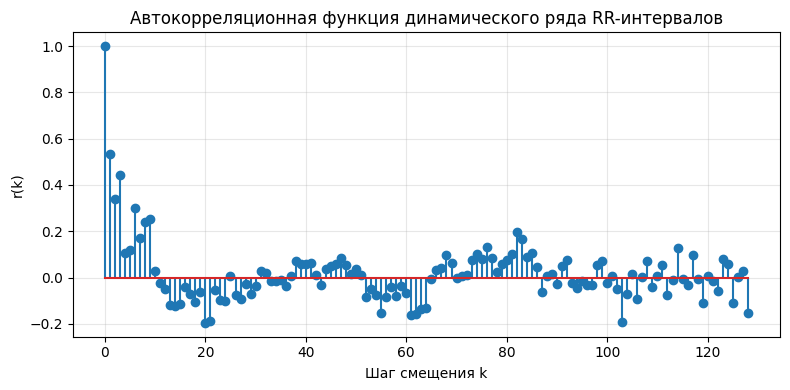

In [15]:
plt.figure(figsize=(8, 4))
plt.stem(k_vals, r)
plt.xlabel("Шаг смещения k")
plt.ylabel("r(k)")
plt.title("Автокорреляционная функция динамического ряда RR-интервалов")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Корреляционная ритмограмма (скаттерограмма)

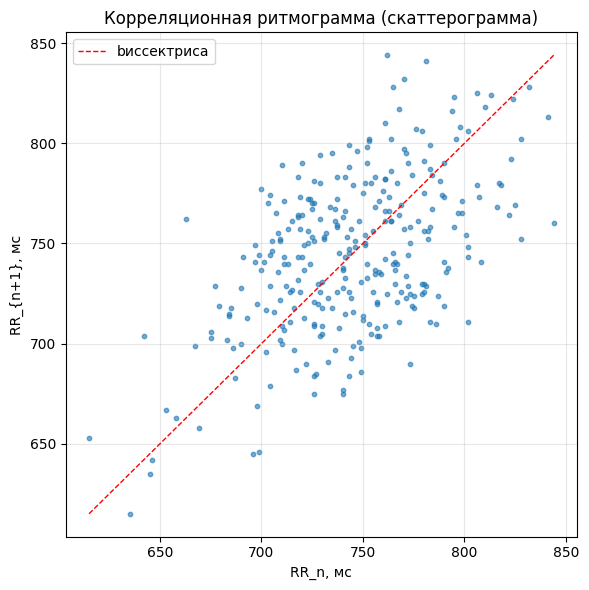

In [16]:
# Используем последовательные пары (RR_n, RR_{n+1})
x_scatter = rr[:-1]
y_scatter = rr[1:]

plt.figure(figsize=(6, 6))
plt.scatter(x_scatter, y_scatter, s=10, alpha=0.6)
plt.xlabel("RR_n, мс")
plt.ylabel("RR_{n+1}, мс")
plt.title("Корреляционная ритмограмма (скаттерограмма)")
plt.grid(True, alpha=0.3)

# Добавим биссектрису для наглядности
min_val = min(rr.min(), rr.min())
max_val = max(rr.max(), rr.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1, label="bиссектриса")
plt.legend()
plt.tight_layout()
plt.show()

## Часть 3. Спектральный анализ.

Прочтя отчёт до половины, я очутился в сумрачном лесу...

In [17]:
times = np.cumsum(rr)
times = times / 1000

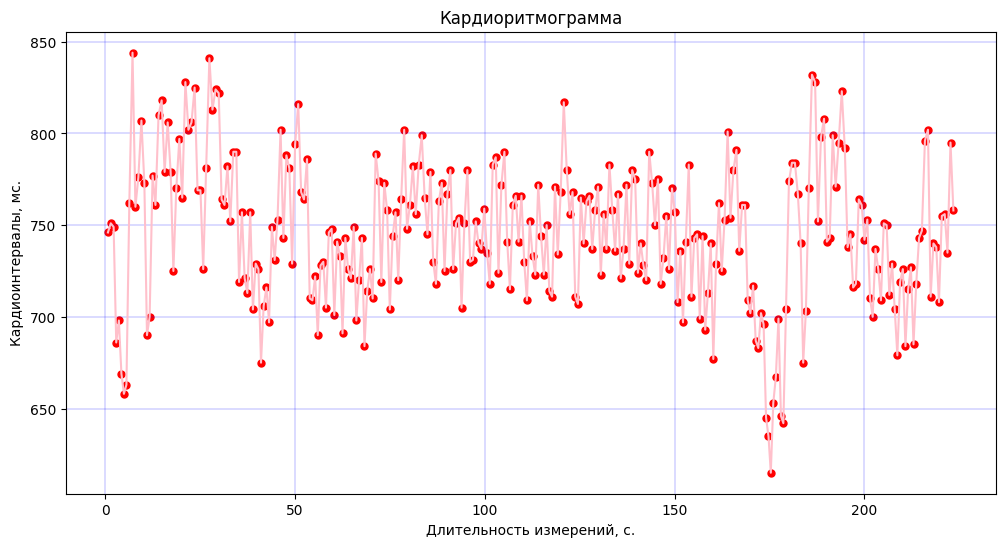

In [18]:
plt.figure(figsize=(12, 6))
plt.grid(color='blue', linewidth = 0.2)
plt.xlabel('Длительность измерений, c.')
plt.ylabel('Кардиоинтервалы, мc.')
plt.title('Кардиоритмограмма')
plt.plot(times, rr, color='pink')
plt.scatter(times, rr, color='red', s=25)

In [19]:
from scipy.interpolate import CubicSpline

In [20]:
time_intervals = np.arange(0, max(times), 0.25) # 0.25 = 250 ms
interpolation_function = CubicSpline(times, rr)

interpolated_values = interpolation_function(time_intervals)

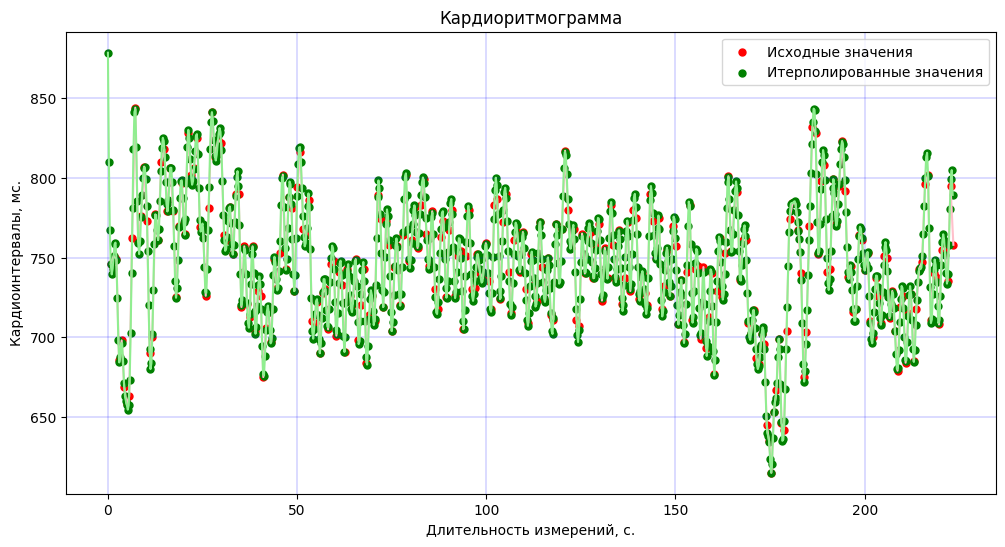

In [21]:
plt.figure(figsize=(12, 6))
plt.grid(color='blue', linewidth = 0.2)
plt.xlabel('Длительность измерений, c.')
plt.ylabel('Кардиоинтервалы, мc.')
plt.title('Кардиоритмограмма')
plt.plot(times, rr, color='pink')
plt.scatter(times, rr, color='red', s=25, label='Исходные значения')
plt.plot(time_intervals, interpolated_values, color='lightgreen')
plt.scatter(time_intervals, interpolated_values, color='green', s=25, label='Итерполированные значения')
plt.legend()

In [22]:
import math

def hanning_window(signal: np.array):
  N = len(signal)
  result_signal = np.zeros(N)
  for n in range(N):
    result_signal[n] = 0.5 * (1 - math.cos(2 * math.pi * n / N)) * signal[n]
  return result_signal

In [23]:
def discrete_fourier_transform(signal: np.array) -> np.array:
  N = len(signal)
  transformed_data = np.zeros(N, dtype=complex)
  for k in range(N):
    real = 0.0
    imag = 0.0
    for n in range(N):
      real += signal[n] * math.cos(-2 * math.pi * k * n/N)
      imag += signal[n] * math.sin(-2 * math.pi * k * n/N)
    transformed_data[k] = complex(real, imag)
  return transformed_data

In [24]:
after_hanning_values = hanning_window(interpolated_values)
transformed_data = discrete_fourier_transform(after_hanning_values)

/tmp/ipython-input-1158617530.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


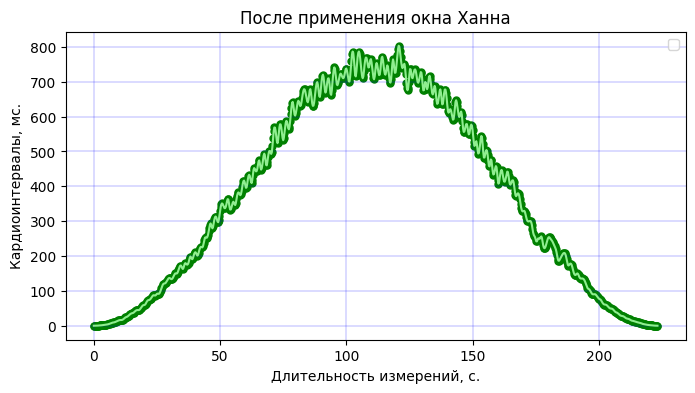

In [25]:
plt.figure(figsize=(8, 4))
plt.grid(color='blue', linewidth = 0.2)
plt.xlabel('Длительность измерений, c.')
plt.ylabel('Кардиоинтервалы, мc.')
plt.title('После применения окна Ханна')
plt.plot(time_intervals, after_hanning_values, color='lightgreen')
plt.scatter(time_intervals, after_hanning_values, color='green', s=25)
plt.legend()

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipython-input-1849135698.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


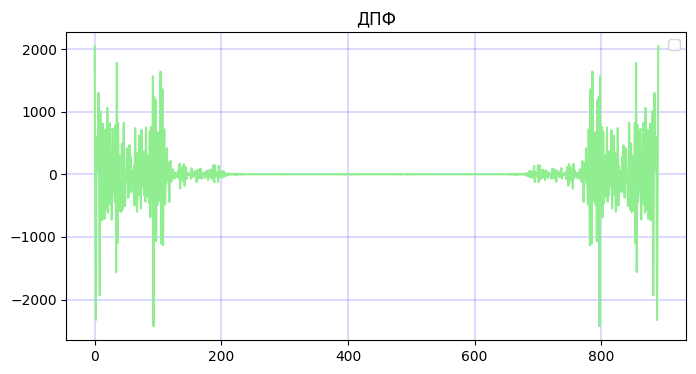

In [26]:
plt.figure(figsize=(8, 4))
plt.grid(color='blue', linewidth = 0.2)
plt.title('ДПФ')
plt.plot(transformed_data[2:len(transformed_data) - 1], color='lightgreen')
plt.legend()

In [27]:
bands = {
    "HF": (0.15, 0.4),
    "LF": (0.04, 0.15),
    "VLF": (0.015, 0.04),
    "ULF": (0.005, 0.015)
}

In [28]:
delta_t = 0.250
fs = 1 / delta_t
f0 = fs / len(interpolated_values)
hight_border = fs / 2
print("Частота дискретизации:", fs)
print("Верхняя граница частот:", hight_border)
print("Нижняя граница частот:", f0)

Частота дискретизации: 4.0
Верхняя граница частот: 2.0
Нижняя граница частот: 0.0044742729306487695


In [29]:
def get_frequences_in_hz(N: int, f0: float):
  return [k  * f0 for k in range(N)]

In [30]:
frequences = get_frequences_in_hz(len(transformed_data), f0)

In [31]:
def calculate_psd(dft_data: np.array) -> np.array:
  N = len(dft_data)
  psd = np.zeros(N)
  for k in range(N):
    psd[k] = (dft_data[k].real * dft_data[k].real + dft_data[k].imag * dft_data[k].imag) / (N * N)
  return psd

In [32]:
psd = calculate_psd(transformed_data)

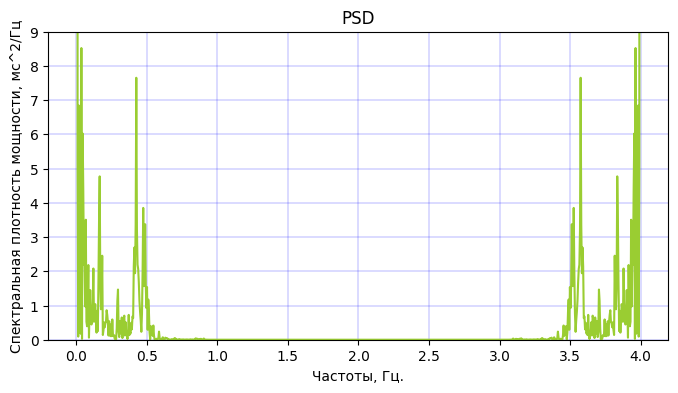

In [33]:
plt.figure(figsize=(8, 4))
plt.grid(color='blue', linewidth = 0.2)
plt.xlabel('Частоты, Гц.')
plt.ylabel('Спектральная плотность мощности, мc^2/Гц')
plt.title('PSD')
plt.ylim((0, 9))
plt.plot(frequences, psd, color='yellowgreen')

In [34]:
psd_df = pd.DataFrame({"PSD": psd, "frequences": frequences})
psd_df = psd_df[psd_df['frequences'] <= hight_border]
psd_df['PSD'] *= 2

In [35]:
masks = []
for key in bands:
  mask = (psd_df['frequences'] >= bands[key][0]) & (psd_df['frequences'] < bands[key][1])
  masks.append(mask)

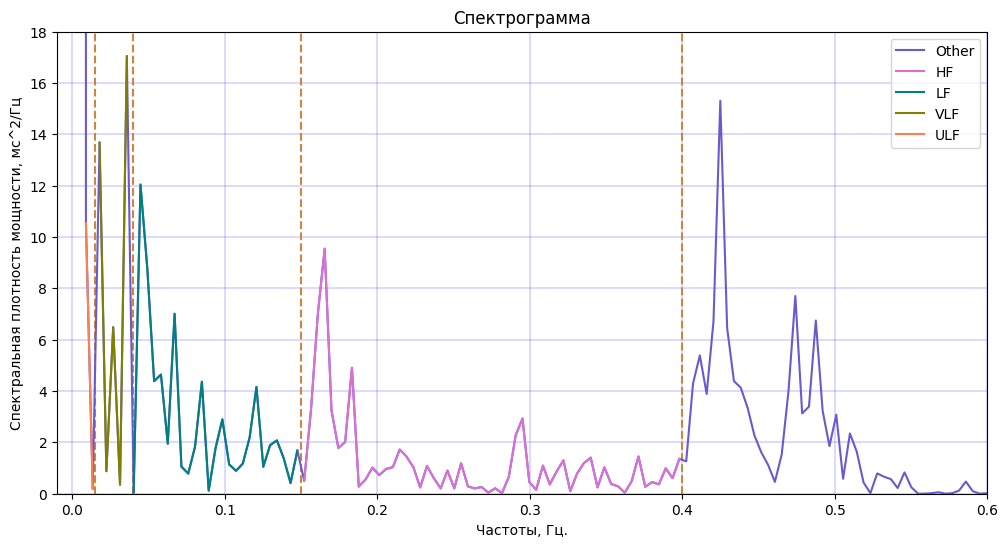

In [36]:
ylim = (0, 18)
xlim = (-0.01, 0.6)
plt.figure(figsize=(12, 6))
plt.grid(color='blue', linewidth = 0.2)
plt.xlabel('Частоты, Гц.')
plt.ylabel('Спектральная плотность мощности, мc^2/Гц')
plt.title('Спектрограмма')
plt.ylim(ylim)
plt.xlim(xlim)

plt.vlines([bands['HF'][1], bands['LF'][1], bands['VLF'][1], bands['ULF'][1]], ylim[0], ylim[1], color='peru', linestyles='--')

plt.plot(psd_df['frequences'], psd_df['PSD'], color='slateblue', label='Other',)
plt.plot(psd_df['frequences'][masks[0]], psd_df['PSD'][masks[0]], color='orchid', label='HF')
plt.plot(psd_df['frequences'][masks[1]], psd_df['PSD'][masks[1]], color='teal', label='LF')
plt.plot(psd_df['frequences'][masks[2]], psd_df['PSD'][masks[2]], color='olive', label='VLF')
plt.plot(psd_df['frequences'][masks[3]], psd_df['PSD'][masks[3]], color='coral', label='ULF')


plt.legend()

In [37]:
hf_power_min = psd_df['PSD'][masks[0]].min()
hf_power_max = psd_df['PSD'][masks[0]].max()

lf_power_min = psd_df['PSD'][masks[1]].min()
lf_power_max = psd_df['PSD'][masks[1]].max()

vlf_power_min = psd_df['PSD'][masks[2]].min()
vlf_power_max = psd_df['PSD'][masks[2]].max()

ulf_power_min = psd_df['PSD'][masks[3]].min()
ulf_power_max = psd_df['PSD'][masks[3]].max()

print(f"Мощность HF минимальная: {hf_power_min}, максимальная: {hf_power_max}")
print(f"Мощность LF минимальная: {lf_power_min}, максимальная: {lf_power_max}")
print(f"Мощность VLF минимальная: {vlf_power_min}, максимальная: {vlf_power_max}")
print(f"Мощность ULF минимальная: {ulf_power_min}, максимальная: {ulf_power_max}")


Мощность HF минимальная: 0.023246565011143434, максимальная: 9.546225937753642
Мощность LF минимальная: 0.048828907221635104, максимальная: 12.04728238971837
Мощность VLF минимальная: 0.34993919497657733, максимальная: 17.045951269196408
Мощность ULF минимальная: 0.18256623492455012, максимальная: 10.539919857210563


In [38]:
hf_power = psd_df['PSD'][masks[0]].sum()
lf_power = psd_df['PSD'][masks[1]].sum()
vlf_power = psd_df['PSD'][masks[2]].sum()
ulf_power = psd_df['PSD'][masks[3]].sum()
total_power = hf_power + lf_power + vlf_power + ulf_power

print("Суммарная мощность HF:", hf_power)
print("Суммарная мощность LF:", lf_power)
print("Суммарная мощность VLF:", vlf_power)
print("Суммарная мощность ULF:", ulf_power)
print("Суммарная мощность:", total_power)

Суммарная мощность HF: 68.08991571837868
Суммарная мощность LF: 69.74209527735843
Суммарная мощность VLF: 38.44672770469377
Суммарная мощность ULF: 10.722486092135114
Суммарная мощность: 187.001224792566


In [39]:
hf_percent_power = hf_power * 100/total_power
lf_percent_power = lf_power * 100/total_power
vlf_percent_power = vlf_power * 100/total_power
ulf_percent_power = ulf_power * 100/total_power

print(f"Относительная мощность HF: {hf_percent_power:.2f}%")
print(f"Относительная мощность LF: {lf_percent_power:.2f}%")
print(f"Относительная мощность VLF: {vlf_percent_power:.2f}%")
print(f"Относительная мощность ULF: {ulf_percent_power:.2f}%")

Относительная мощность HF: 36.41%
Относительная мощность LF: 37.29%
Относительная мощность VLF: 20.56%
Относительная мощность ULF: 5.73%


Относительная мощность LF низкочастоной составляющей спектра находится в норме. Мощность "очень" низкочастотной составляющей спектра также лежит в диапазоне нормы 15-30%

In [40]:
IC = (vlf_power + lf_power) / hf_power
IVI = lf_power / hf_power
ISCA = lf_power / vlf_power
print("Индекс централизации ИЦ", IC)
print("Индекс вагосимпатического взаимодействия ИВВ", IVI)
print("Индекс активации подкорковых нервных центров ИАП", ISCA)


Индекс централизации ИЦ 1.58891110145478
Индекс вагосимпатического взаимодействия ИВВ 1.0242646732860297
Индекс активации подкорковых нервных центров ИАП 1.8139930090550713


## Часть 4. Вычисление показателя активности регуляторных систем (ПАРС).

In [41]:
class PARS_builder():
  def __init__(self):
    self.points: int = 0
    self.stability_of_regulation: bool = True

  def add_total_regulation_effect(self, HR: float):
    points = 0
    if HR < 51:
      points = -2
    elif HR >= 51 and HR < 60:
      points = -1
    elif HR >= 60 and HR < 80:
      pass
    elif HR >= 80 and HR < 90:
      points = 1
    elif HR >= 90:
      points = 2
    print(f"HR:{HR} => {points}")
    self.points += (points)
    return self

  def add_automation_functions(self, MxDMn: float, CV: float):
    points = 0
    if MxDMn <= 60 and CV <= 2:
      points = 2
    elif (MxDMn > 60 and MxDMn < 150) and (CV > 2.0 and CV <= 4.0):
      points = 1
    elif (MxDMn >= 150 and MxDMn <= 300):
      pass
    elif (MxDMn > 300 and MxDMn <= 500):
      points = -1
    elif  MxDMn > 500:
      points = -2
    print(f"MxDMn:{MxDMn}, CV {CV} => {points}")
    self.points += (points)
    return self

  def add_vegetative_homeostasis(self, MxDMn: float, AMo: float):
    points = 0
    if MxDMn <= 60 and AMo > 80:
      points = 2
    elif (MxDMn > 60 and MxDMn < 150) and (AMo >= 51 and AMo <= 80):
      points = 1
    elif (MxDMn >= 150 and MxDMn <= 300) and (AMo >= 30 and AMo < 51):
      pass
    elif (MxDMn > 300 and MxDMn <= 500) and (AMo >= 20 and AMo < 30):
      points = -1
    elif  MxDMn > 500 and AMo < 20:
      points = -2
    print(f"MxDMn:{MxDMn}, AMo {AMo} => {points}")
    self.points += (points)
    return self

  def add_stability_of_regulation(self, CV: float, SI: float):
    if CV > 15 and SI < 15:
      self.stability_of_regulation = False
    return self

  def add_vasomotor_center(self, LF: float):
    points = 0
    if LF >= 55:
      points = 2
    elif LF >= 40 and LF < 55:
      points = 1
    elif LF >= 20 and LF < 40:
      pass
    elif LF >= 11  and LF < 20:
      points = -1
    elif LF < 11:
      points = -2

    print(f"LF:{LF} => {points}")
    self.points += (points)
    return self

  def add_sympathetic_cardiovascular_subcortical_nerve_center(self, VLF: float):
    points = 0
    if VLF >= 60:
      points = 2
    elif VLF >= 45 and VLF < 60:
      points = 1
    elif VLF >= 25 and VLF < 45:
      pass
    elif VLF >= 16  and VLF < 25:
      points = -1
    elif VLF < 16:
      points = -2

    print(f"VLF:{VLF} => {points}")
    self.points += (points)
    return self

  def calculate_pars(self):
    return self.points

In [42]:
pars_builder = PARS_builder()
pars_builder.add_total_regulation_effect(HR) \
            .add_automation_functions(MxDMn, CV) \
            .add_vegetative_homeostasis(MxDMn, AMo) \
            .add_stability_of_regulation(CV, SI) \
            .add_vasomotor_center(lf_percent_power) \
            .add_sympathetic_cardiovascular_subcortical_nerve_center(vlf_percent_power)

HR:80.55853920515575 => 1
MxDMn:229.0, CV 5.1957512975336 => 0
MxDMn:229.0, AMo 43.333333333333336 => 0
LF:37.29499384547931 => 0
VLF:20.55961277651598 => -1


In [43]:
print(f"ПАРС составил: {pars_builder.calculate_pars()} очков")

ПАРС составил: 0 очков


🟢 Из полученного значения ПАРС, можно сделать вывод, что испытуемый находился в состояние оптимального (рабочего) напряжения регуляторных систем,
необходимое для поддержания активного равновесия организма со средой.

Или иначе, находился в состоянии нормы или состоянии удовлетворительной адаптации.

## Часть 5. Обобщение и дополнение.

In [44]:
class StatisticsMethods():
  def __init__(self):
    self.bin_width = 50
    self.bins_range = (400, 1300)
    self.image_size = (10, 5)

    self.rr_intervals = []
    self.HR = 0
    self.mean = 0
    self.SDNN = 0
    self.CV = 0
    self.RMSSD = 0
    self.pNN50 = 0
    self.mode = 0
    self.AMo = 0
    self.Mx = 0
    self.Mn = 0
    self.MxDMn = 0
    self.SI = 0
    self.bins = []

  def calculate_metrics(self, rr_intervals: list[int]):
    self.rr_intervals = rr_intervals.copy()
    self._calculate_statistics(self.rr_intervals)
    self._calculate_histogram_metrics(self.rr_intervals)

  def _calculate_statistics(self, rr_intervals: list[int]):
    self.HR = 60 * 1000 * len(rr_intervals) / sum(rr_intervals)
    self.mean = rr_intervals.mean()
    self.SDNN = rr_intervals.std(ddof=1)
    self.CV = self.SDNN / self.mean * 100
    diffs = np.diff(rr_intervals)
    self.RMSSD = np.sqrt(np.mean(diffs**2))
    self.pNN50 = np.sum(np.abs(diffs) > 50) / len(diffs) * 100
    self.Mx = rr_intervals.max()
    self.Mn = rr_intervals.min()
    self.MxDMn = self.Mx - self.Mn

  def _calculate_histogram_metrics(self, rr_intervals: list[int]):
    n = len(rr_intervals)
    self.bins = np.arange(self.bins_range[0],  self.bins_range[1] + self.bin_width, self.bin_width)
    hist_counts, bin_edges = np.histogram(rr_intervals, bins=self.bins)
    rel_freq = hist_counts / n
    idx_mode = np.argmax(hist_counts)
    Mo_left = bin_edges[idx_mode]
    Mo_right = bin_edges[idx_mode + 1]
    self.mode = (Mo_left + Mo_right) / 2
    self.AMo = hist_counts[idx_mode] / n * 100
    self.SI = self.AMo / (2 * self.mode * self.MxDMn) * 1_000_000


  def print_values(self):
    print(f"HR\t= {self.HR:.2f} ударов в 1 мин")
    print(f"Mean\t= {self.mean:.2f} мс")
    print(f"SDNN\t= {self.SDNN:.2f} мс")
    print(f"CV\t= {self.CV:.2f} %")
    print(f"RMSSD\t= {self.RMSSD:.2f} мс")
    print(f"pNN50\t= {self.pNN50:.2f} %")
    print(f"Моde\t= {self.mode:.1f} мс")
    print(f"АМо\t= {self.AMo:.2f} %")
    print(f"Mx\t= {self.Mx:.1f} мс")
    print(f"Mn\t= {self.Mn:.1f} мс")
    print(f"MxDMn\t= {self.MxDMn:.1f} мс")
    print(f"SI\t= {self.SI:.2f} усл. ед.")

  def plot_histogram(self):
    plt.figure(figsize=self.image_size)
    plt.hist(self.rr_intervals, bins=self.bins, density=True, edgecolor='black', alpha=0.7)

    plt.title("Вариационная пульсограмма (RR-интервалы)")
    plt.xlabel("RR-интервал, мс")
    plt.ylabel("Плотность (отн. частота / 50 мс)")

    plt.axvline(self.mode, color='red', linestyle='--', label=f"Мо ≈ {self.mode:.0f} мс")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [45]:
class AutocorrelationMethods():
  def __init__(self):
    self.image_size = (8, 4)

    self.rr_intervals = []
    self.r = []
    self.k_vals = []
    self.CC0 = 0
    self.CC1 = 0

  def calculate_metrics(self, rr_intervals: list[int]):
    self.rr_intervals = rr_intervals.copy()
    X = self.rr_intervals - self.rr_intervals.mean()
    n = len(self.rr_intervals)
    m = min(128, n - 2)
    r = []
    for k in range(0, m + 1):
        Xi = X[:n - k]
        Xk = X[k:]
        cov = np.mean((Xi - Xi.mean()) * (Xk - Xk.mean()))
        std1 = Xi.std(ddof=0)
        std2 = Xk.std(ddof=0)
        if std1 == 0 or std2 == 0:
            rk = 0.0
        else:
            rk = cov / (std1 * std2)
        r.append(rk)

    self.r = np.array(r)
    self.k_vals = np.arange(0, m + 1)
    self.CC1 = r[1]
    neg_indices = np.where(self.r < 0)[0]
    if len(neg_indices) > 0:
        self.CC0 = int(neg_indices[0])  # первый k, при котором r(k) < 0
    else:
        self.CC0 = m

  def print_values(self):
    print(f"CC1 (r(1)) = {self.CC1:.4f}")
    print(f"CC0 (первый шаг, где r(k) < 0) = {self.CC0}")

  def plot_autocorrelation(self):
    plt.figure(figsize=self.image_size)
    plt.stem(self.k_vals, self.r)
    plt.xlabel("Шаг смещения k")
    plt.ylabel("r(k)")
    plt.title("Автокорреляционная функция динамического ряда RR-интервалов")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

  def plot_scattergram(self, scale_coef=1):
    x_scatter = self.rr_intervals[:-1]
    y_scatter = self.rr_intervals[1:]

    plt.figure(figsize=self.image_size)
    plt.scatter(x_scatter, y_scatter, s=10, alpha=0.6)
    plt.xlabel("RR_n, мс")
    plt.ylabel("RR_{n+1}, мс")
    plt.title("Корреляционная ритмограмма (скаттерограмма)")
    plt.grid(True, alpha=0.3)

    # Добавим биссектрису для наглядности
    min_val = min(self.rr_intervals.min()/scale_coef, self.rr_intervals.min()/scale_coef)
    max_val = max(self.rr_intervals.max()*scale_coef, self.rr_intervals.max()*scale_coef)
    plt.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1, label="bиссектриса")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [46]:
class SpectralAnalysis():
  def __init__(self):
    self.delta_t = 0.25
    self.bands = {
      "HF": (0.15, 0.4),
      "LF": (0.04, 0.15),
      "VLF": (0.015, 0.04),
      "ULF": (0.005, 0.015)
    }
    self.ylim = (0, 18)
    self.xlim = (-0.01, 0.6)
    self.image_size = (12, 6)

    self.rr_intervals = []
    self.times = []
    self.time_intervals = []
    self.interpolated_rr = []
    self.transformed_rr = []
    self.fs = 0
    self.f0 = 0
    self.hight_frequency_border = 0
    self.frequences = []
    self.psd_df = pd.DataFrame()
    self.masks = []
    self.hf_power_min = 0
    self.hf_power_max = 0
    self.lf_power_min = 0
    self.lf_power_max = 0
    self.vlf_power_min = 0
    self.vlf_power_max = 0
    self.ulf_power_min = 0
    self.ulf_power_max = 0
    self.hf_power = 0
    self.lf_power = 0
    self.vlf_power = 0
    self.ulf_power = 0
    self.total_power = 0
    self.hf_percent_power = 0
    self.lf_percent_power = 0
    self.vlf_percent_power =0
    self.ulf_percent_power =0
    self.IC = 0
    self.IVI = 0
    self.ISCA = 0

  def calculate_metrics(self, rr_intervals: list[int]):
    self.rr_intervals = rr_intervals.copy()
    times = np.cumsum(self.rr_intervals)
    times = times / 1000
    self.times = times
    self.time_intervals = np.arange(0, max(times), self.delta_t)
    interpolation_function = CubicSpline(times, self.rr_intervals)
    interpolated_values = interpolation_function(self.time_intervals)
    self.interpolated_rr = interpolated_values
    after_hanning_values = hanning_window(self.interpolated_rr)
    self.transformed_rr = discrete_fourier_transform(after_hanning_values)
    self.fs = 1 / self.delta_t
    self.f0 = self.fs / len(self.interpolated_rr)
    self.hight_frequency_border = self.fs / 2
    frequences = get_frequences_in_hz(len(self.transformed_rr), self.f0)
    psd = calculate_psd(self.transformed_rr)
    self.psd_df = self._process_psd(psd, frequences)
    self._calculate_masks()
    self._calculate_band_power()

  def _process_psd(self, psd: np.array, frequences: np.array):
    psd_df = pd.DataFrame({"PSD": psd, "frequences": frequences})
    psd_df = psd_df[psd_df['frequences'] <= self.hight_frequency_border]
    psd_df['PSD'] *= 2
    return psd_df

  def _calculate_masks(self):
    masks = []
    for key in self.bands:
      mask = (self.psd_df['frequences'] >= self.bands[key][0]) & (self.psd_df['frequences'] < self.bands[key][1])
      masks.append(mask)
    self.masks = masks

  def _calculate_band_power(self, include_ULF: bool = False):
    self.hf_power_min = self.psd_df['PSD'][self.masks[0]].min()
    self.hf_power_max = self.psd_df['PSD'][self.masks[0]].max()
    self.lf_power_min = self.psd_df['PSD'][self.masks[1]].min()
    self.lf_power_max = self.psd_df['PSD'][self.masks[1]].max()
    self.vlf_power_min = self.psd_df['PSD'][self.masks[2]].min()
    self.vlf_power_max = self.psd_df['PSD'][self.masks[2]].max()
    self.ulf_power_min = self.psd_df['PSD'][self.masks[3]].min()
    self.ulf_power_max = self.psd_df['PSD'][self.masks[3]].max()
    self.hf_power = self.psd_df['PSD'][self.masks[0]].sum()
    self.lf_power = self.psd_df['PSD'][self.masks[1]].sum()
    self.vlf_power = self.psd_df['PSD'][self.masks[2]].sum()
    self.ulf_power = self.psd_df['PSD'][self.masks[3]].sum()
    if include_ULF == True:
      self.total_power = self.hf_power + self.lf_power + self.vlf_power + self.ulf_power
      self.ulf_percent_power = self.ulf_power * 100/self.total_power
    else:
      self.total_power = self.hf_power + self.lf_power + self.vlf_power
      self.ulf_percent_power = 0
    self.hf_percent_power = self.hf_power * 100/self.total_power
    self.lf_percent_power = self.lf_power * 100/self.total_power
    self.vlf_percent_power = self.vlf_power * 100/self.total_power
    self.ylim = (0, max(self.hf_power_max, self.lf_power_max, self.vlf_power_max))
    self.IC = (self.vlf_power + self.lf_power) / self.hf_power
    self.IVI = self.lf_power / self.hf_power
    self.ISCA = self.lf_power / self.vlf_power

  def plot_cardiac_rhythmogram(self):
    plt.figure(figsize=self.image_size)
    plt.grid(color='blue', linewidth = 0.2)
    plt.xlabel('Длительность измерений, c.')
    plt.ylabel('Кардиоинтервалы, мc.')
    plt.title('Кардиоритмограмма')
    plt.plot(self.times, self.rr_intervals, color='pink')
    plt.scatter(self.times, self.rr_intervals, color='red', s=25)

  def plot_spectrogram(self):
    plt.figure(figsize=self.image_size)
    plt.grid(color='blue', linewidth = 0.2)
    plt.xlabel('Частоты, Гц.')
    plt.ylabel('Спектральная плотность мощности, мc^2/Гц')
    plt.title('Спектрограмма')
    plt.ylim(self.ylim)
    plt.xlim(self.xlim)

    plt.vlines([self.bands['HF'][1], self.bands['LF'][1], self.bands['VLF'][1],
                self.bands['ULF'][1]], self.ylim[0], self.ylim[1], color='peru',
                linestyles='--')

    plt.plot(self.psd_df['frequences'], self.psd_df['PSD'], color='slateblue', label='Other',)
    plt.plot(self.psd_df['frequences'][self.masks[0]], self.psd_df['PSD'][self.masks[0]], color='orchid', label='HF')
    plt.plot(self.psd_df['frequences'][self.masks[1]], self.psd_df['PSD'][self.masks[1]], color='teal', label='LF')
    plt.plot(self.psd_df['frequences'][self.masks[2]], self.psd_df['PSD'][self.masks[2]], color='olive', label='VLF')
    plt.plot(self.psd_df['frequences'][self.masks[3]], self.psd_df['PSD'][self.masks[3]], color='coral', label='ULF')

    plt.legend()

  def print_values(self):
    print("Частота дискретизации:", self.fs)
    print("Верхняя граница частот:", self.hight_frequency_border)
    print("Нижняя граница частот:", self.f0)
    print(f"Мощность HF минимальная: {self.hf_power_min}, максимальная: {self.hf_power_max}")
    print(f"Мощность LF минимальная: {self.lf_power_min}, максимальная: {self.lf_power_max}")
    print(f"Мощность VLF минимальная: {self.vlf_power_min}, максимальная: {self.vlf_power_max}")
    print(f"Мощность ULF минимальная: {self.ulf_power_min}, максимальная: {self.ulf_power_max}")
    print("Суммарная мощность HF:", self.hf_power)
    print("Суммарная мощность LF:", self.lf_power)
    print("Суммарная мощность VLF:", self.vlf_power)
    print("Суммарная мощность ULF:", self.ulf_power)
    print("Суммарная мощность:", self.total_power)
    print(f"Относительная мощность HF: {self.hf_percent_power:.2f}%")
    print(f"Относительная мощность LF: {self.lf_percent_power:.2f}%")
    print(f"Относительная мощность VLF: {self.vlf_percent_power:.2f}%")
    print(f"Относительная мощность ULF: {self.ulf_percent_power:.2f}%")
    print("Индекс централизации ИЦ", self.IC)
    print("Индекс вагосимпатического взаимодействия ИВВ", self.IVI)
    print("Индекс активации подкорковых нервных центров ИАП", self.ISCA)


In [57]:
class TotalAnalyzer():
  def __init__(self):
    self.statistics_analysis = StatisticsMethods()
    self.ac_analysis = AutocorrelationMethods()
    self.spectral_analysis = SpectralAnalysis()

  def calculate_metrics(self, rr_intervals: list[int]):
    self.statistics_analysis.calculate_metrics(rr_intervals)
    self.ac_analysis.calculate_metrics(rr_intervals)
    self.spectral_analysis.calculate_metrics(rr_intervals)

  def plot_graphics(self):
    self.statistics_analysis.plot_histogram()
    self.ac_analysis.plot_autocorrelation()
    self.ac_analysis.plot_scattergram(1.4)
    self.spectral_analysis.plot_cardiac_rhythmogram()
    self.spectral_analysis.plot_spectrogram()

  def pars_index(self):
    print('\n\n==================ПАРС анализ==================')
    pars_builder = PARS_builder()
    pars_builder.add_total_regulation_effect(self.statistics_analysis.HR) \
            .add_automation_functions(self.statistics_analysis.MxDMn, self.statistics_analysis.CV) \
            .add_vegetative_homeostasis(self.statistics_analysis.MxDMn, self.statistics_analysis.AMo) \
            .add_stability_of_regulation(self.statistics_analysis.CV, self.statistics_analysis.SI) \
            .add_vasomotor_center(self.spectral_analysis.lf_percent_power) \
            .add_sympathetic_cardiovascular_subcortical_nerve_center(self.spectral_analysis.vlf_percent_power)
    print(f"ПАРС: {pars_builder.calculate_pars()}, abs: {abs(pars_builder.calculate_pars())}")

  def print_values(self):
    self.statistics_analysis.print_values()
    self.ac_analysis.print_values()
    self.spectral_analysis.print_values()


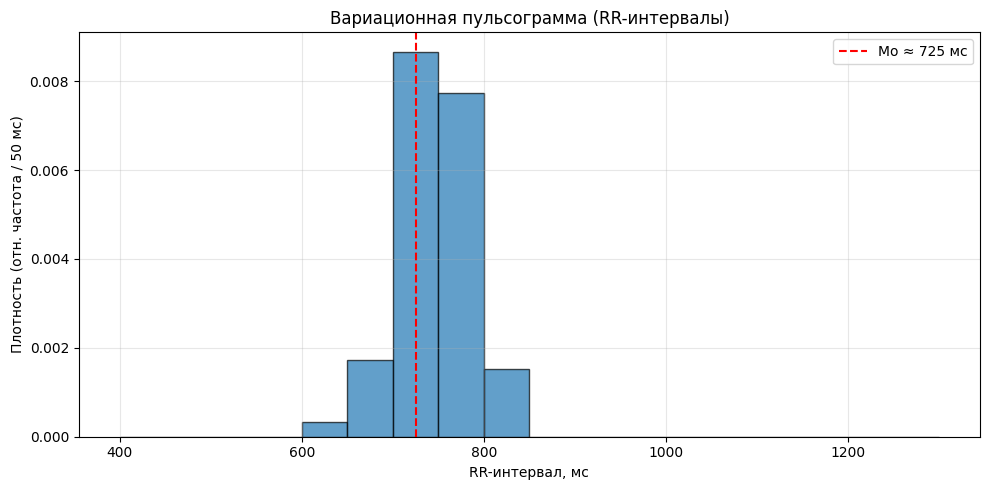

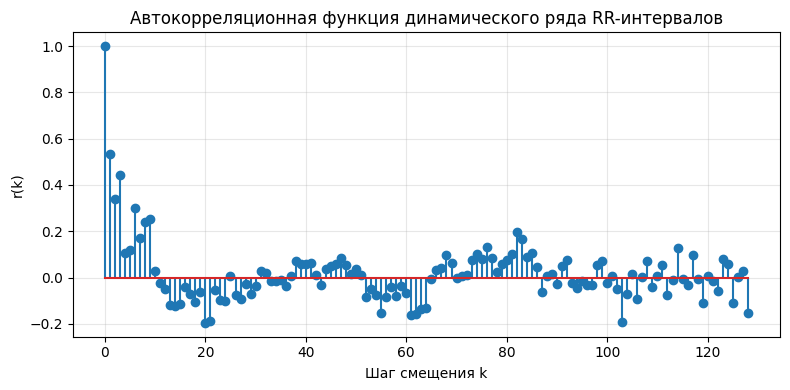

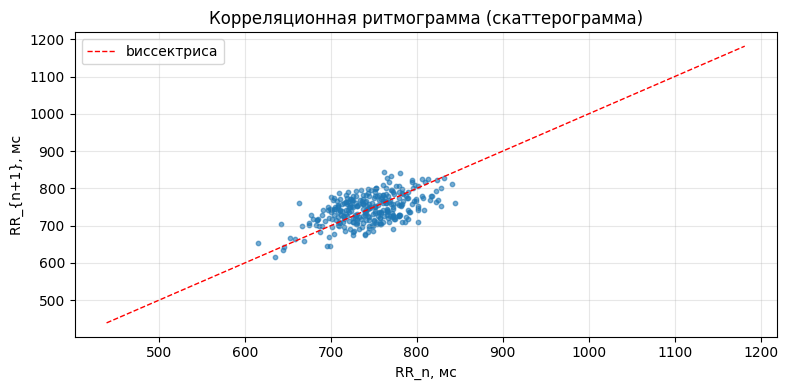

HR	= 80.56 ударов в 1 мин
Mean	= 744.80 мс
SDNN	= 38.70 мс
CV	= 5.20 %
RMSSD	= 37.40 мс
pNN50	= 19.06 %
Моde	= 725.0 мс
АМо	= 43.33 %
Mx	= 844.0 мс
Mn	= 615.0 мс
MxDMn	= 229.0 мс
SI	= 130.50 усл. ед.
CC1 (r(1)) = 0.5329
CC0 (первый шаг, где r(k) < 0) = 11
Частота дискретизации: 4.0
Верхняя граница частот: 2.0
Нижняя граница частот: 0.0044742729306487695
Мощность HF минимальная: 0.023246565011143434, максимальная: 9.546225937753642
Мощность LF минимальная: 0.048828907221635104, максимальная: 12.04728238971837
Мощность VLF минимальная: 0.34993919497657733, максимальная: 17.045951269196408
Мощность ULF минимальная: 0.18256623492455012, максимальная: 10.539919857210563
Суммарная мощность HF: 68.08991571837868
Суммарная мощность LF: 69.74209527735843
Суммарная мощность VLF: 38.44672770469377
Суммарная мощность ULF: 10.722486092135114
Суммарная мощность: 176.2787387004309
Относительная мощность HF: 38.63%
Относительная мощность LF: 39.56%
Относительная мощность VLF: 21.81%
Относительная мощн

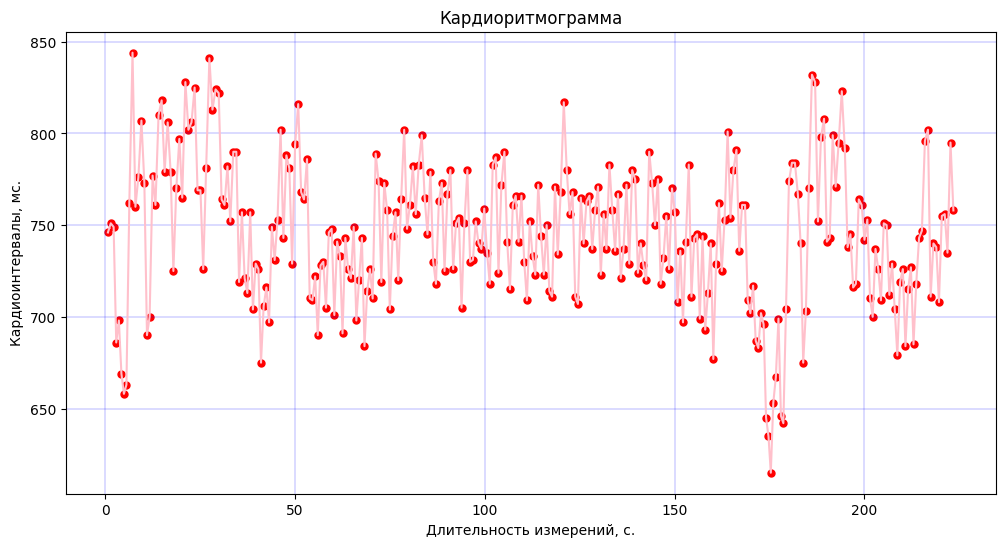

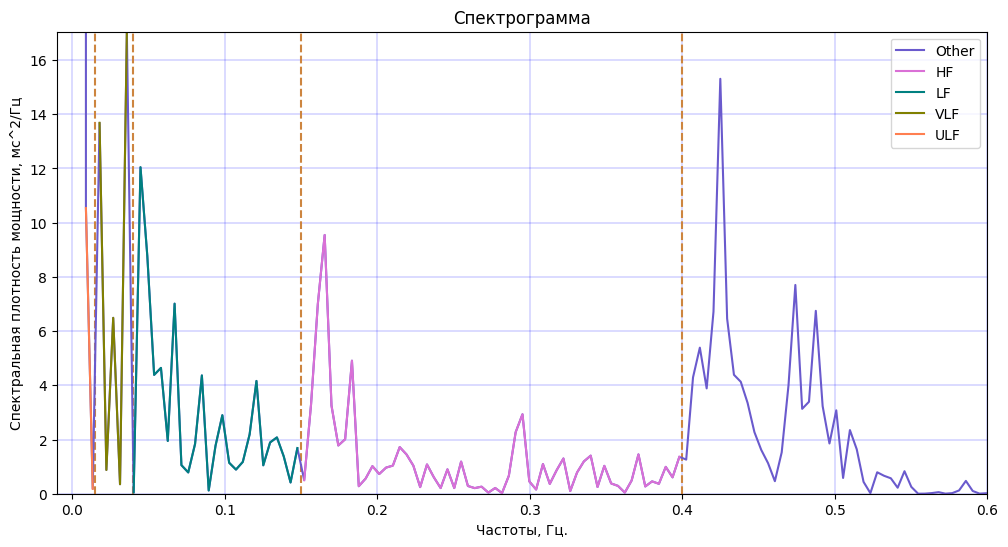

In [58]:
ta = TotalAnalyzer()
ta.calculate_metrics(rr)
ta.plot_graphics()
ta.print_values()
ta.pars_index()

## Часть 6. Другие данные

Были взяты данные из следующего датасета: https://physionet.org/content/mvtdb/1.0/RRdata1/#files-panel


Испытуемый 1: Желудочковая тахикардия (ЖТ)

In [60]:
test_filename = '0003.vt1'

In [61]:
test_rr = pd.read_csv(test_filename, header=None)[0].to_numpy(dtype=float)
test_n = len(test_rr)
print(f"Число интервалов n = {test_n}")

Число интервалов n = 1024


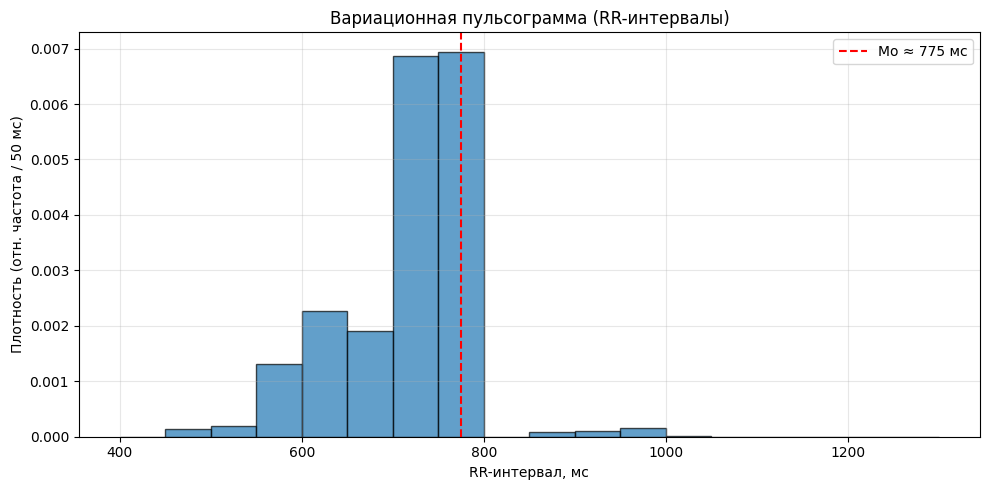

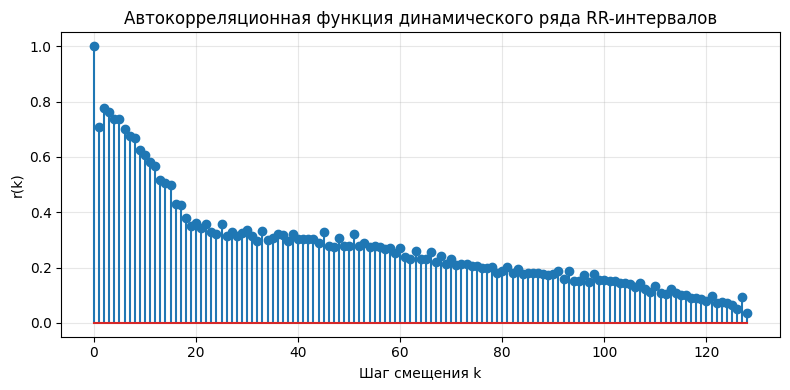

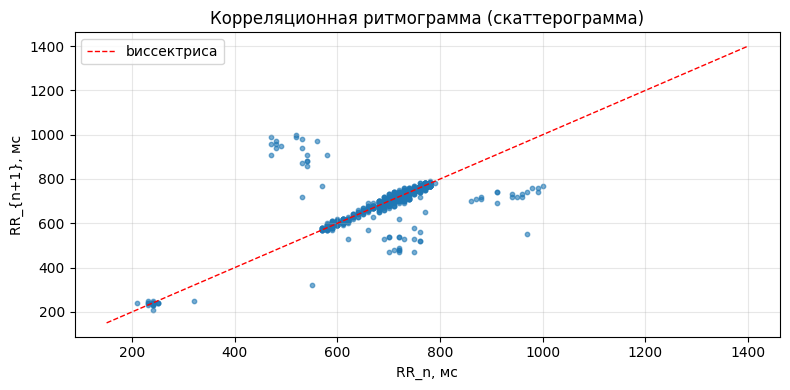

HR	= 85.59 ударов в 1 мин
Mean	= 701.02 мс
SDNN	= 94.69 мс
CV	= 13.51 %
RMSSD	= 72.05 мс
pNN50	= 6.06 %
Моde	= 775.0 мс
АМо	= 34.08 %
Mx	= 1000.0 мс
Mn	= 210.0 мс
MxDMn	= 790.0 мс
SI	= 27.83 усл. ед.
CC1 (r(1)) = 0.7071
CC0 (первый шаг, где r(k) < 0) = 128
Частота дискретизации: 4.0
Верхняя граница частот: 2.0
Нижняя граница частот: 0.001392757660167131
Мощность HF минимальная: 0.0024395093316264987, максимальная: 1.2784092687632864
Мощность LF минимальная: 0.0003887750498521079, максимальная: 1.5206377281160572
Мощность VLF минимальная: 0.1718470914786107, максимальная: 11.303510314027957
Мощность ULF минимальная: 0.7447489864766496, максимальная: 119.11497554854687
Суммарная мощность HF: 47.80373522505637
Суммарная мощность LF: 12.309816972995336
Суммарная мощность VLF: 70.46665665691417
Суммарная мощность ULF: 221.82914441860763
Суммарная мощность: 130.58020885496586
Относительная мощность HF: 36.61%
Относительная мощность LF: 9.43%
Относительная мощность VLF: 53.96%
Относительная м

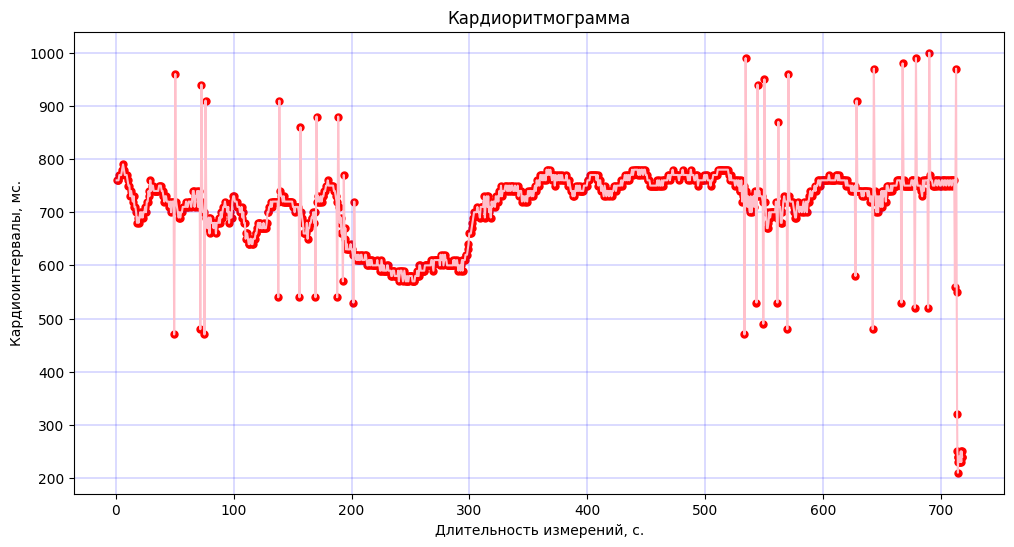

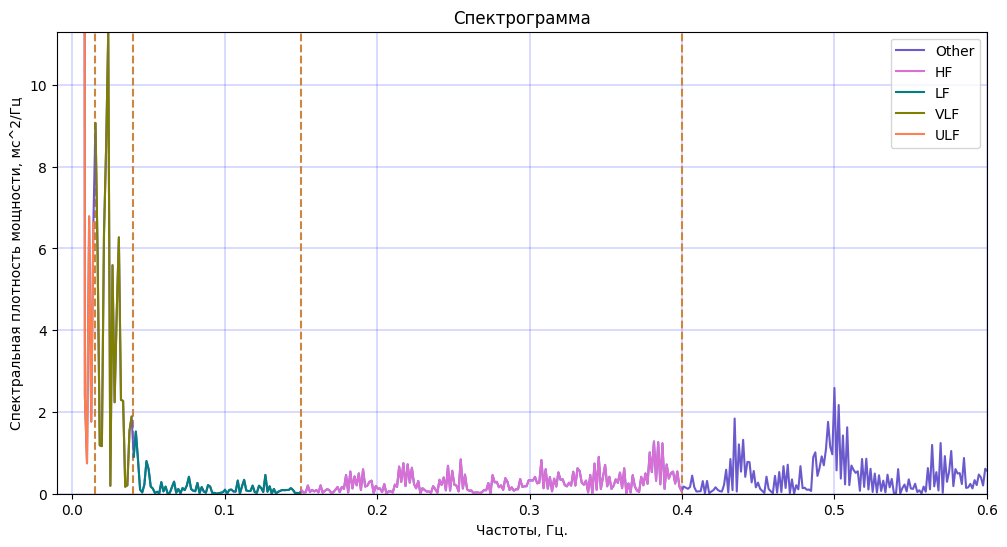

In [62]:
ta = TotalAnalyzer()
ta.calculate_metrics(test_rr)
ta.plot_graphics()
ta.print_values()
ta.pars_index()

Испытуемый 2: Фибрилляция желудочков (ФЖ)

In [63]:
test_filename = '0030.vf2'

In [64]:
test_rr = pd.read_csv(test_filename, header=None)[0].to_numpy(dtype=float)
test_n = len(test_rr)
print(f"Число интервалов n = {test_n}")

Число интервалов n = 1024


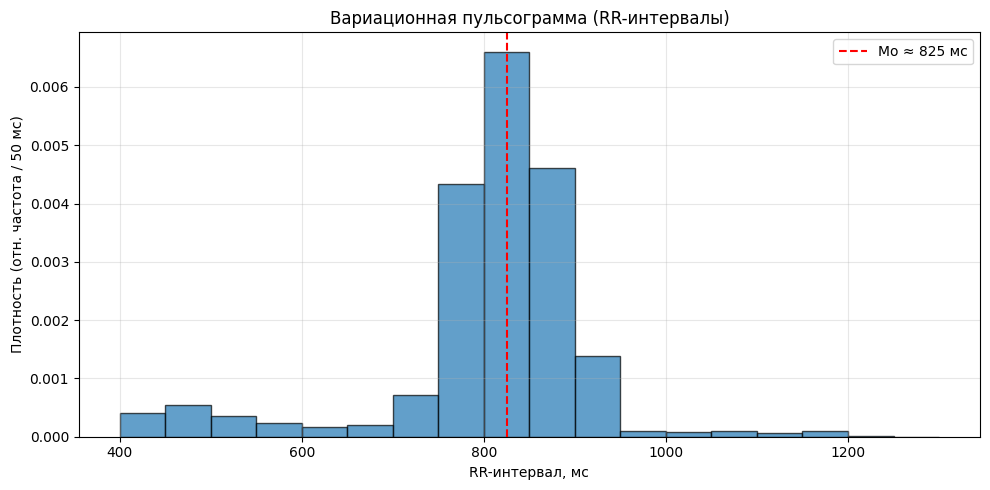

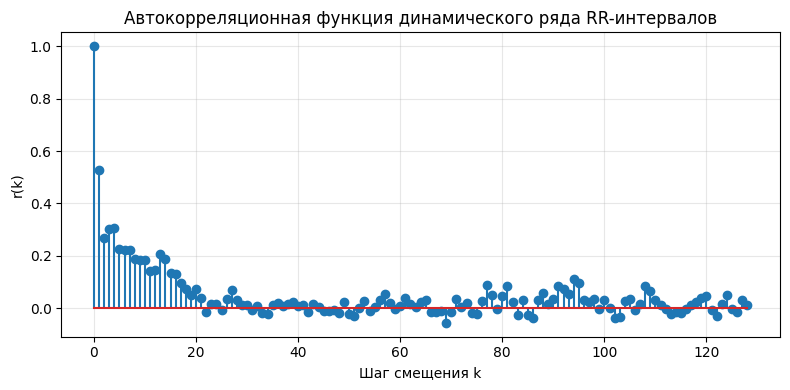

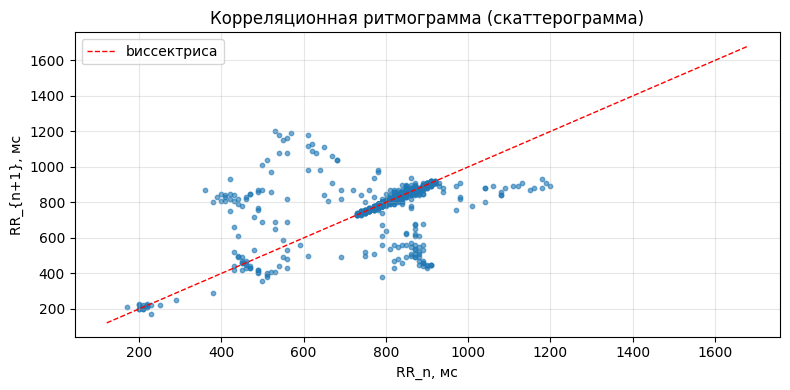

HR	= 76.04 ударов в 1 мин
Mean	= 789.03 мс
SDNN	= 137.33 мс
CV	= 17.40 %
RMSSD	= 132.76 мс
pNN50	= 16.91 %
Моde	= 825.0 мс
АМо	= 32.32 %
Mx	= 1200.0 мс
Mn	= 170.0 мс
MxDMn	= 1030.0 мс
SI	= 19.02 усл. ед.
CC1 (r(1)) = 0.5280
CC0 (первый шаг, где r(k) < 0) = 22
Частота дискретизации: 4.0
Верхняя граница частот: 2.0
Нижняя граница частот: 0.0012376237623762376
Мощность HF минимальная: 0.019527475391408984, максимальная: 50.455763980253764
Мощность LF минимальная: 0.20269448637399937, максимальная: 42.198874865008044
Мощность VLF минимальная: 1.8896408833191172, максимальная: 14.160857942056468
Мощность ULF минимальная: 0.9978052761445796, максимальная: 46.25717199325351
Суммарная мощность HF: 2181.415451350279
Суммарная мощность LF: 854.6731016603482
Суммарная мощность VLF: 118.59093317203416
Суммарная мощность ULF: 119.46771495451756
Суммарная мощность: 3154.679486182661
Относительная мощность HF: 69.15%
Относительная мощность LF: 27.09%
Относительная мощность VLF: 3.76%
Относительная мо

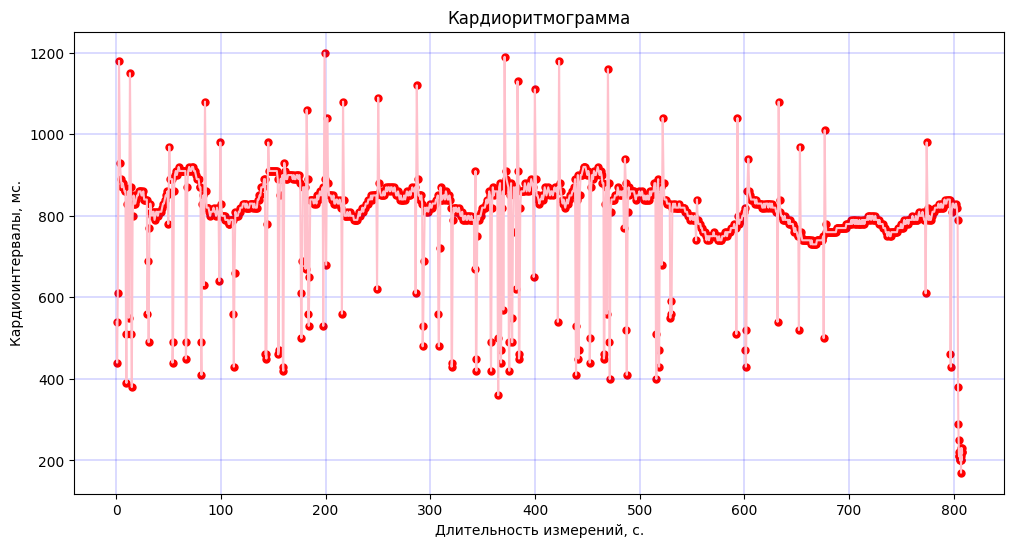

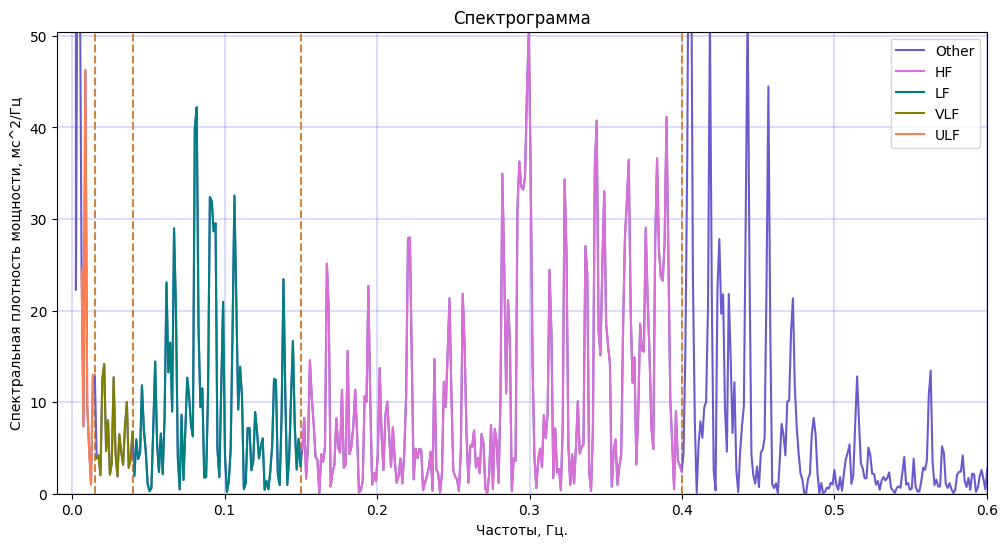

In [65]:
ta = TotalAnalyzer()
ta.calculate_metrics(test_rr)
ta.plot_graphics()
ta.print_values()
ta.pars_index()